In [27]:
import sys
from pathlib import Path

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "raw_data").exists())
sys.path.insert(0, str(REPO / "processing_data"))

import geopandas as gpd
import shapely
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from scipy import stats

import explore_cache as xc

pd.set_option("display.width", 200, "display.precision", 3)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})
FIG = REPO / "figures" / "rebuild"
FIG.mkdir(parents=True, exist_ok=True)
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

a2 = xc.admin2()
a0 = a2.dissolve()
a1 = a2.dissolve(by="adm1_name").reset_index()
print(f"{len(a2)} counties in {a2.adm1_name.nunique()} states/areas;")

79 counties in 11 states/areas;


## 1. Data audit: what the flood record can and cannot tell us

Three properties of the flood masks decide how every later result must be read.

In [22]:
cells = xc.flood_cells_monthly()
lut = xc.cell_admin2()
audit = xc.flood_file_audit()

north = a2.cx[:, 10:]
a2m = a2.to_crs(6933)
north_box = gpd.GeoSeries([shapely.geometry.box(20, 10, 40, 20)], crs=4326).to_crs(6933)
frac_area = a2m.clip(north_box).area.sum() / a2m.area.sum()
print("Tile coverage of the flood product:")
print(f"  share of South Sudan that is not covered: {frac_area:.1%}")
print("  counties reaching north of 10 N(not covered):", ", ".join(sorted(north.adm2_name)))

print("\ncloud_frac over every file:",
      np.nanmax(audit.filter(like="cloud_max").to_numpy()))
print("pixel-days flagged both recurring and unusual:", f"{audit.overlap_rows.sum():,}")

Tile coverage of the flood product:
  share of South Sudan that is not covered: 6.2%
  counties reaching north of 10 N(not covered): Abyei Region, Baliet, Fashoda, Maban, Manyo, Melut, Pariang, Raja, Renk

cloud_frac over every file: 0.0
pixel-days flagged both recurring and unusual: 0


Coverage of flooding \
flooding coverage stops at 10 degrees north. Everything more north than that, including some of the Upper Nile is missing. Malakal discharge station thankfully is inside that.

Clouds and dry observations\
The dataset doesnt include any pixels that are NOT flood pixels and it does not include any clouded pixels. So if a pixel is missing it could either be dry or clouded. All detection will be a lower bound because it is biased in the cloudier months, like the rain season.

mean detection have increased from 2000-2018 to 2021-2025: x14.1


year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
flood_type,,,,,,,,,,,,,,,,,,,,,
recurring,2129.000,11180.000,43612.000,133166.000,72499.000,85821.000,126685.000,2.375e+05,3.571e+05,182979.000,...,209629.000,176468.000,175530.0,136253.000,4.305e+05,5.080e+05,5.225e+05,3.856e+05,5.065e+05,3.414e+05
unusual,9062.000,12665.000,72315.000,187402.000,106160.000,274405.000,564533.000,9.383e+05,9.193e+05,743036.000,...,398664.000,296367.000,297294.0,336267.000,2.056e+06,3.090e+06,7.840e+06,1.192e+07,9.512e+06,8.805e+06
total,11191.000,23845.000,115927.000,320568.000,178659.000,360226.000,691218.000,1.176e+06,1.276e+06,926015.000,...,608293.000,472835.000,472824.0,472520.000,2.486e+06,3.598e+06,8.363e+06,1.230e+07,1.002e+07,9.147e+06
km2_days,601.912,1282.511,6235.173,17241.859,9609.235,19374.878,37177.395,6.324e+04,6.866e+04,49806.032,...,32717.246,25431.591,25431.0,25414.649,1.337e+05,1.935e+05,4.498e+05,6.618e+05,5.388e+05,4.920e+05


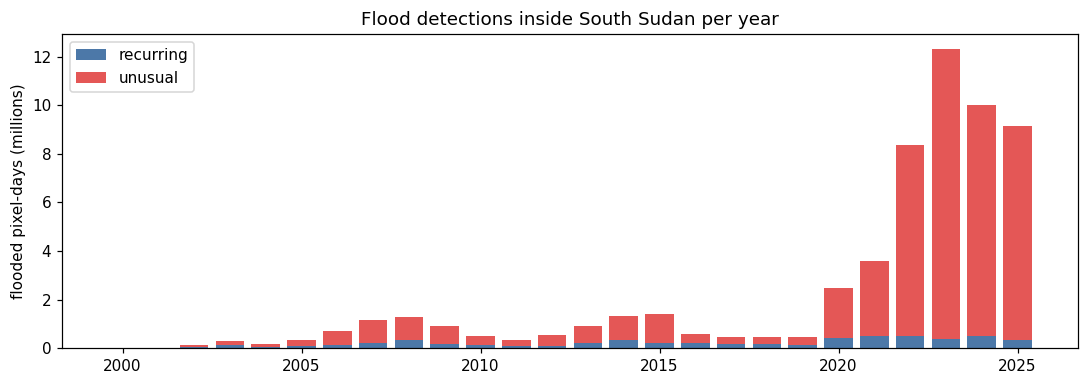

In [23]:
ssd = cells.merge(lut, on=["cell_lat", "cell_lon"], how="inner")
yearly = ssd.groupby(["year", "flood_type"]).pixeldays.sum().unstack().rename(columns={0: "recurring", 1: "unusual"})
yearly["total"] = yearly.sum(axis=1)
yearly["km2_days"] = yearly.total * xc.PIXEL_KM2

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.bar(yearly.index, yearly.recurring / 1e6, label="recurring", color="#4c78a8")
ax.bar(yearly.index, yearly.unusual / 1e6, bottom=yearly.recurring / 1e6, label="unusual", color="#e45756")
ax.set_ylabel("flooded pixel-days (millions)")
ax.set_title("Flood detections inside South Sudan per year")
ax.legend()
fig.tight_layout(); fig.savefig(FIG / "01_detections_per_year.png", bbox_inches="tight")

ratio = yearly.total.loc[2021:2025].mean() / yearly.total.loc[2000:2018].mean()
print(f"mean detection have increased from 2000-2018 to 2021-2025: x{ratio:.1f}")
yearly.T

Detection volume has increased\
Mean detection in recent years are 14 times as much as those from 2000 to 2018. But this doesnt necessarily mean more flooding. Since this is satelite data most probably an increase in detection is due to the sensor.

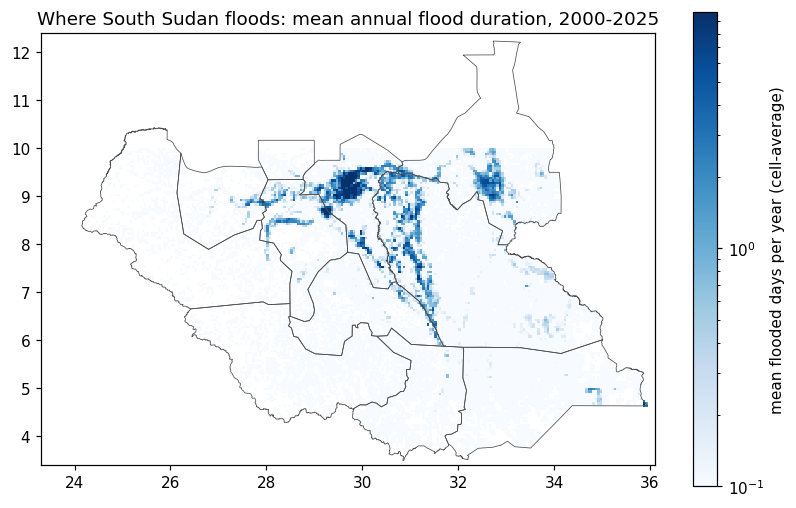

In [24]:
coarse = 0.05
f = ssd.assign(clat=(np.floor(ssd.cell_lat / coarse) * coarse + coarse / 2).round(3),
               clon=(np.floor(ssd.cell_lon / coarse) * coarse + coarse / 2).round(3))
cell_km2 = (coarse * 111.32) ** 2 * np.cos(np.deg2rad(f.clat.unique().mean()))
grid = f.groupby(["clat", "clon"]).pixeldays.sum() * xc.PIXEL_KM2 / cell_km2 / len(xc.YEARS)
grid = grid.unstack()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.pcolormesh(grid.columns, grid.index, grid.values, cmap="Blues",
                   norm=mcolors.LogNorm(vmin=0.1, vmax=np.nanpercentile(grid.values, 99.5)), shading="nearest")
a1.boundary.plot(ax=ax, color="0.3", lw=0.5)
fig.colorbar(im, ax=ax, label="mean flooded days per year (cell-average)", shrink=0.8)
ax.set_title("Where South Sudan floods: mean annual flood duration, 2000-2025")
ax.set_xlim(23.3, 36.1); ax.set_ylim(3.4, 12.4); ax.set_aspect("equal")
fig.savefig(FIG / "01_flood_heatmap_space.png", bbox_inches="tight")

Flooding is highly concentrated:\
the northern Sudd around Bentiu/Rubkona, the most persistent hotspot;\
the Bahr el Jebel / White Nile corridor running south-north through Jonglei and Lakes;\
the Machar marshes / Sobat in Upper Nile;\
east-west river channels in the north-west ( the Lol / Bahr el Arab / Jur systems feeding the Bahr el Ghazal).\

The south barely flood at all.

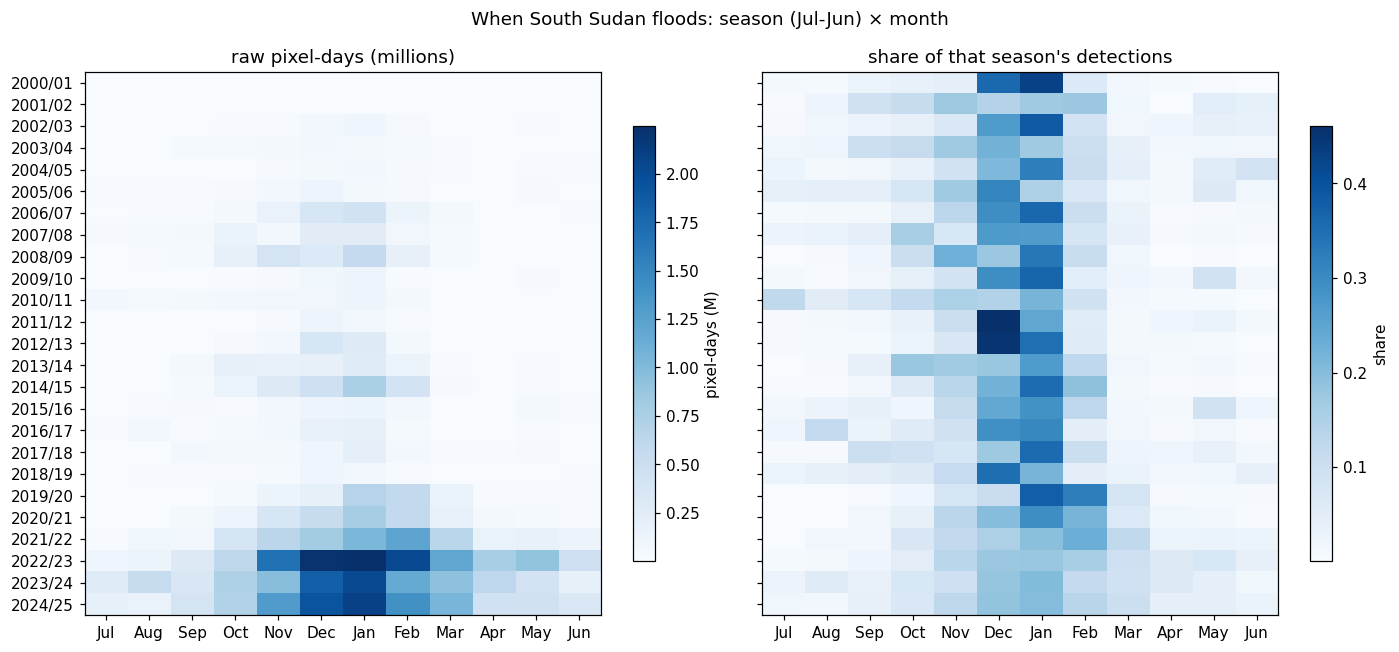

In [28]:
wy_order = [7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6]
wy_labels = [months[m - 1] for m in wy_order]
ssd["wy"] = ssd.year - (ssd.month <= 6)
ym = (ssd[ssd.wy.between(2000, 2024)].groupby(["wy", "month"]).pixeldays.sum()
      .unstack().reindex(columns=wy_order).fillna(0))
share = ym.div(ym.sum(axis=1), axis=0)

fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
for ax, data, title, lab in [(axs[0], ym / 1e6, "raw pixel-days (millions)", "pixel-days (M)"),
                             (axs[1], share, "share of that season's detections", "share")]:
    im = ax.imshow(data.values, aspect="auto", cmap="Blues", origin="upper")
    ax.set_xticks(range(12), wy_labels); ax.set_yticks(range(len(data)), [f"{y}/{str(y+1)[2:]}" for y in data.index])
    ax.set_title(title); fig.colorbar(im, ax=ax, label=lab, shrink=0.8)
fig.suptitle("When South Sudan floods: season (Jul-Jun) × month")
fig.tight_layout(); fig.savefig(FIG / "01_flood_heatmap_yearmonth.png", bbox_inches="tight")

In [30]:
clim = share.mean()
print("mean within-season share of detections per month (%):")
print((clim * 100).round(1).rename(dict(enumerate(months, 1))).to_string())
print(f"\npeak month: {months[clim.idxmax()-1]};  share in Nov-Jan: {clim.loc[[11, 12, 1]].sum():.0%};  "
      f"share in Jul-Sep: {clim.loc[[7, 8, 9]].sum():.0%}")
pk = share.idxmax(axis=1)
print("peak month per season:", pk.map(lambda m: months[m-1]).value_counts().to_string().replace("\n", ", "))


mean within-season share of detections per month (%):
month
Jul     1.6
Aug     2.1
Sep     3.5
Oct     6.8
Nov    11.7
Dec    24.2
Jan    28.0
Feb    11.8
Mar     3.8
Apr     1.6
May     3.0
Jun     1.8

peak month: Jan;  share in Nov-Jan: 64%;  share in Jul-Sep: 7%
peak month per season: Jan    17, Dec     6, Feb     2


The flood season is usually late but regular\
Detections of flood build from Octomber to January where they peak (17 out of 25 peaked in January) and then go down from March.\
About two thirds of each years flooding happens between November and January and only 7% happens in the rain season(July to September).\
So national flooding is about 5 months after the rainfall peak. Evidence that the flooding is not driven by local rain.

In [ ]:
era = xc.era5_daily()
lat, lon = era.latitude.values, era.longitude.values
LON, LAT = np.meshgrid(lon, lat)
pts = gpd.GeoDataFrame(geometry=gpd.points_from_xy(LON.ravel(), LAT.ravel()), crs=4326)
inside = gpd.sjoin(pts, a0[["geometry"]], predicate="within").index
mask = np.zeros(LON.size, bool); mask[inside] = True; mask = mask.reshape(LON.shape)
print(f"ERA5 cells inside South Sudan: {mask.sum()}\n  days: {era.sizes['time']:,}")

def national_mean(var):
    w = np.cos(np.deg2rad(LAT)) * mask
    return pd.Series((era[var].values * w).sum((1, 2)) / w.sum(), index=pd.DatetimeIndex(era.time.values), name=var)

rain = national_mean("tp"); runoff = national_mean("ro")

ERA5 cells inside South Sudan: 838  |  days: 9,497  (2000-01-01 to 2025-12-31)


annual rainfall across South Sudan: 332-3575 mm; 99th pct 1715 mm


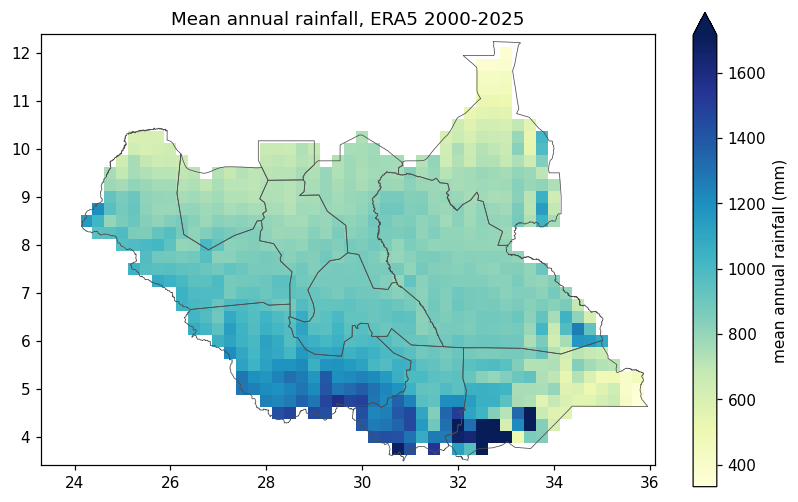

In [31]:
annual_tp = np.where(mask, era.tp.groupby("time.year").sum().mean("year").values, np.nan)
p99 = np.nanpercentile(annual_tp, 99)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.pcolormesh(lon, lat, annual_tp, cmap="YlGnBu", shading="nearest", vmax=p99)
a1.boundary.plot(ax=ax, color="0.3", lw=0.5)
fig.colorbar(im, ax=ax, label="mean annual rainfall (mm)", shrink=0.8, extend="max")
ax.set_title("Mean annual rainfall, ERA5 2000-2025")
ax.set_xlim(23.3, 36.1); ax.set_ylim(3.4, 12.4); ax.set_aspect("equal")
fig.savefig(FIG / "01_rain_heatmap_space.png", bbox_inches="tight")
iy, ix = np.unravel_index(np.nanargmax(annual_tp), annual_tp.shape)
print(f"annual rainfall across South Sudan: {np.nanmin(annual_tp):.0f}-{np.nanmax(annual_tp):.0f} mm; "
      f"99th pct {p99:.0f} mm")

Rainfall decreases from **south to north**: about 1,200-1,700 mm/yr along the Congo-Nile divide in the
Equatorias, and 500-800 mm/yr in Upper Nile and the far south-east (Kapoeta). The single extreme cell
(~3,500 mm, at the Imatong mountains on the Uganda border) is an ERA5 orographic artefact, so the
colour scale is clipped at the 99th percentile.

The places that flood most (the Sudd, the Machar marshes, the north-western channels) sit in the
**drier middle and north**, not where rain is heaviest. That's the first data hint that much of the
flooding is driven by water arriving from upstream, not only by rain falling on the spot.

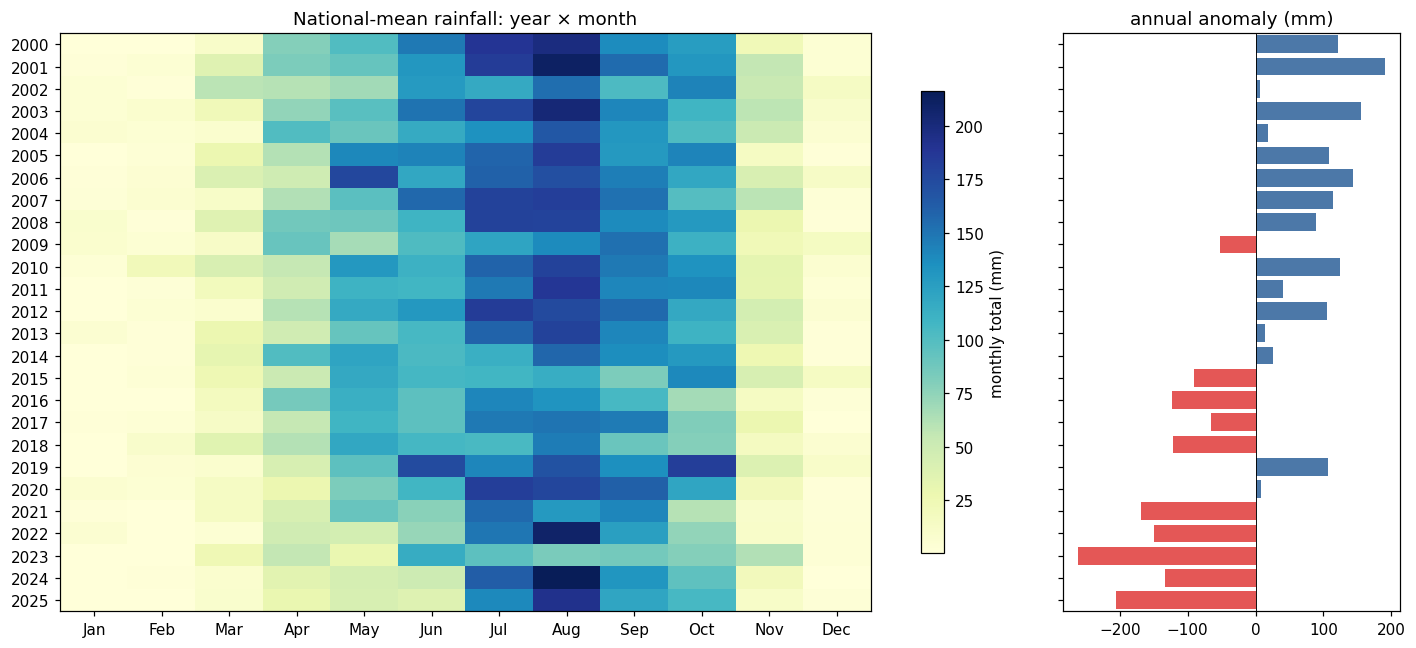

In [9]:
def year_month_heatmap(s, title, cmap, fname, unit):
    t = s.groupby([s.index.year, s.index.month]).sum().unstack()
    fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharey=True, gridspec_kw={"width_ratios": [3, 1]})
    im = axs[0].imshow(t.values, aspect="auto", cmap=cmap)
    axs[0].set_xticks(range(12), MONTHS); axs[0].set_yticks(range(len(t)), t.index)
    fig.colorbar(im, ax=axs[0], label=f"monthly total ({unit})", shrink=0.8)
    anom = t.sum(axis=1) - t.sum(axis=1).mean()
    axs[1].barh(range(len(t)), anom, color=np.where(anom > 0, "#4c78a8", "#e45756"))
    axs[1].set_title(f"annual anomaly ({unit})"); axs[1].axvline(0, color="k", lw=0.6)
    axs[0].set_title(title)
    fig.tight_layout(); fig.savefig(FIG / fname, bbox_inches="tight")
    return t

rain_ym = year_month_heatmap(rain, "National-mean rainfall: year × month", "YlGnBu", "01_rain_heatmap_yearmonth.png", "mm")

In [10]:
def describe(t, name):
    ann = t.sum(axis=1)
    clim = t.mean()
    slope = stats.linregress(ann.index, ann.values)
    out = {
        "mean annual (mm)": ann.mean(), "sd (mm)": ann.std(), "CV": ann.std() / ann.mean(),
        "min year": f"{ann.idxmin()} ({ann.min():.0f})", "max year": f"{ann.idxmax()} ({ann.max():.0f})",
        "trend (mm/decade)": slope.slope * 10, "trend p": slope.pvalue,
        "peak month": MONTHS[clim.idxmax() - 1],
        "share in Jun-Sep": clim.loc[6:9].sum() / clim.sum(),
    }
    return pd.Series(out, name=name)

print("monthly climatology (mm):")
print(rain_ym.mean().rename(dict(enumerate(MONTHS, 1))).round(0).to_string())
ann_rain = rain_ym.sum(axis=1)
print(f"\nmean annual rain 2000-14: {ann_rain.loc[:2014].mean():.0f} mm;  2015-25: {ann_rain.loc[2015:].mean():.0f} mm")
describe(rain_ym, "rainfall").to_frame()

monthly climatology (mm):
Jan      2.0
Feb      4.0
Mar     21.0
Apr     61.0
May     95.0
Jun    111.0
Jul    149.0
Aug    168.0
Sep    132.0
Oct    112.0
Nov     33.0
Dec      5.0

mean annual rain 2000-14: 975 mm;  2015-25: 785 mm


,rainfall
mean annual (mm),894.724
sd (mm),125.509
CV,0.14
min year,2023 (633)
max year,2001 (1085)
trend (mm/decade),-129.557
trend p,0.0
peak month,Aug
share in Jun-Sep,0.627


The rainy season runs **April to October** and peaks in **August**; June-September carries ~63% of the
annual total. The national annual total varies little between years (CV 0.14).

**Unexpected: ERA5 shows strong drying.** The national total falls by about 130 mm per decade (p < 0.001),
and 2015-2025 are almost all below average, with 2023 the driest year on record. This runs opposite to the
reported flood history (record floods in 2020-2022) and to the rising detection counts. Two consequences:
- The raw rain-flood correlation across years will be **biased negative** (rain trends down, detections
  trend up), so **both series must be detrended** before correlating.
- The drying may partly be an ERA5 artefact. It should be cross-checked against an independent product
  (CHIRPS) before anyone builds on rain *levels*. Within-season anomalies are safer than absolute totals.

## 4. Runoff (ERA5)

national runoff ratio: 8.0%;  cell range 0.3%-66.3% (median 4.4%)


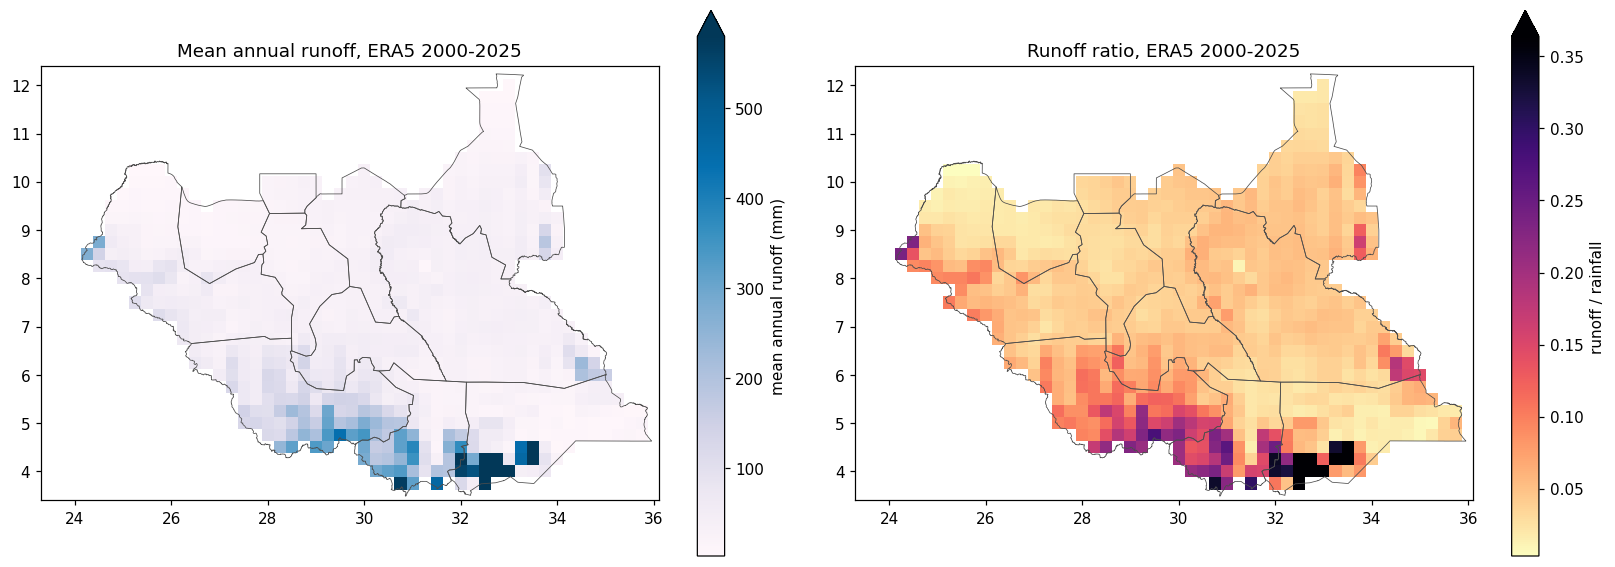

In [11]:
annual_ro = np.where(mask, era.ro.groupby("time.year").sum().mean("year").values, np.nan)
ratio_map = annual_ro / annual_tp

fig, axs = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, data, cmap, lab, ttl in [(axs[0], annual_ro, "PuBu", "mean annual runoff (mm)", "Mean annual runoff"),
                                 (axs[1], ratio_map, "magma_r", "runoff / rainfall", "Runoff ratio")]:
    im = ax.pcolormesh(lon, lat, data, cmap=cmap, shading="nearest", vmax=np.nanpercentile(data, 99))
    a1.boundary.plot(ax=ax, color="0.3", lw=0.5)
    fig.colorbar(im, ax=ax, label=lab, shrink=0.8, extend="max"); ax.set_title(ttl + ", ERA5 2000-2025")
    ax.set_xlim(23.3, 36.1); ax.set_ylim(3.4, 12.4); ax.set_aspect("equal")
fig.tight_layout(); fig.savefig(FIG / "01_runoff_heatmap_space.png", bbox_inches="tight")
print(f"national runoff ratio: {runoff.sum() / rain.sum():.1%};  "
      f"cell range {np.nanmin(ratio_map):.1%}-{np.nanmax(ratio_map):.1%} (median {np.nanmedian(ratio_map):.1%})")

monthly climatology (mm), and runoff as share of that month's rain:
         Jan   Feb   Mar   Apr   May   Jun   Jul    Aug    Sep    Oct   Nov   Dec
runoff  1.57  1.00  1.26  3.02  5.23  5.47  8.82  13.79  11.47  11.68  5.91  2.57
ratio   0.68  0.27  0.06  0.05  0.05  0.05  0.06   0.08   0.09   0.10  0.18  0.51

annual rain vs runoff: r = 0.92 (p = 0.000)


,rainfall,runoff
mean annual (mm),894.724,71.793
sd (mm),125.509,22.697
CV,0.14,0.316
min year,2023 (633),2023 (33)
max year,2001 (1085),2000 (114)
trend (mm/decade),-129.557,-21.161
trend p,0.0,0.0
peak month,Aug,Aug
share in Jun-Sep,0.627,0.551


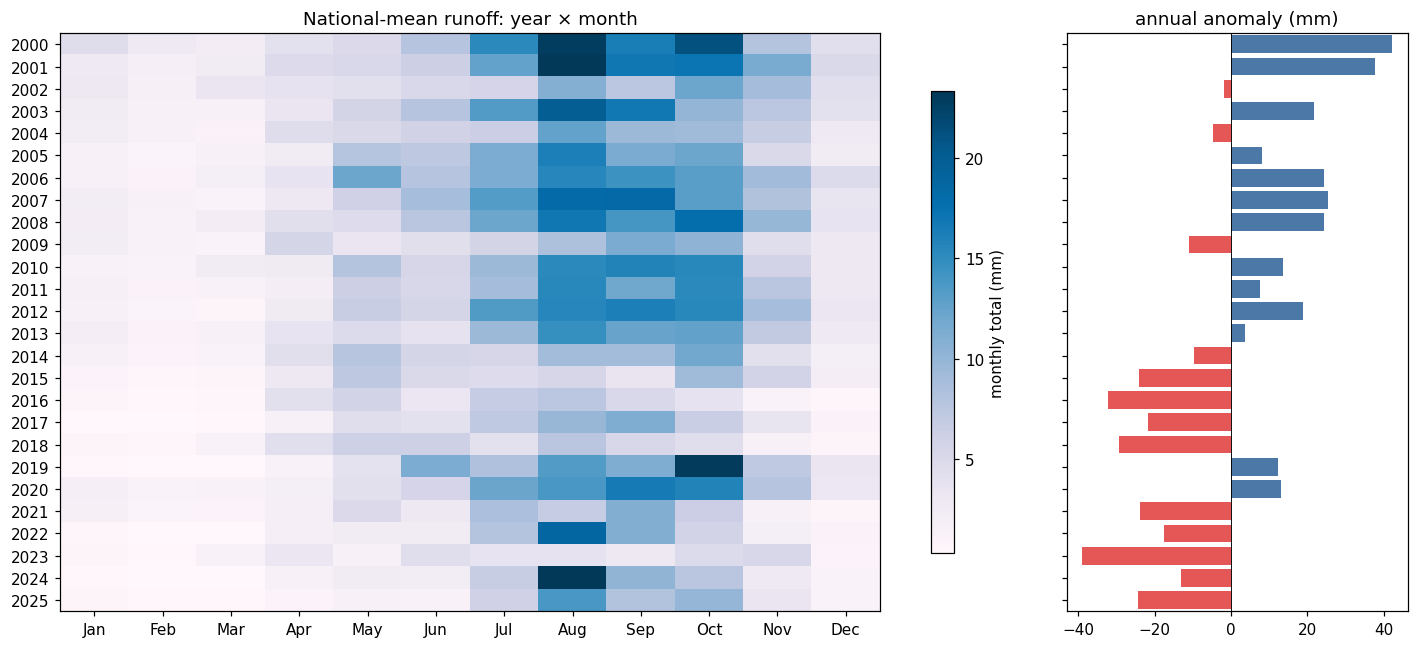

In [12]:
ro_ym = year_month_heatmap(runoff, "National-mean runoff: year × month", "PuBu", "01_runoff_heatmap_yearmonth.png", "mm")
print("monthly climatology (mm), and runoff as share of that month's rain:")
print(pd.DataFrame({"runoff": ro_ym.mean(), "ratio": ro_ym.mean() / rain_ym.mean()})
        .rename(index=dict(enumerate(MONTHS, 1))).round(2).T.to_string())
ann = pd.DataFrame({"rain": rain_ym.sum(axis=1), "runoff": ro_ym.sum(axis=1)})
r = stats.pearsonr(ann.rain, ann.runoff)
print(f"\nannual rain vs runoff: r = {r[0]:.2f} (p = {r[1]:.3f})")
pd.concat([describe(rain_ym, "rainfall"), describe(ro_ym, "runoff")], axis=1)

Only **8%** of rain becomes runoff nationally in ERA5; most of it evaporates or infiltrates. Runoff is
highest in the hilly, wet south (Equatorias, Imatong) and close to zero across the flat plains where
the flooding actually happens.

Runoff varies **more than twice as much between years** as rainfall (CV 0.32 vs 0.14): it responds
non-linearly, because once soils are saturated each extra millimetre runs off. Within the season the
runoff ratio climbs from about 5% in May-June to about 10% in September-October, as soils fill up. So
runoff peaks with rain in August but stays high through October after rain has dropped. Annually it
tracks rain closely (r = 0.92), so as a *yearly* predictor it adds little beyond rainfall. Its value
is as a measure of **how saturated the ground is late in the season**.

*Caveat:* ERA5 runoff is modelled, not observed. It does not represent river routing or the Sudd
wetland storage, which the timing below shows is where the flood signal actually comes from.

## 5. Timing of rain, runoff and flooding together

If local rain drove flooding directly, the flood peak would follow the rain peak within weeks.

centre of mass (months after 1 March): {'rainfall': np.float64(4.4), 'runoff': np.float64(5.3), 'flood extent': np.float64(8.2)}
flood centre lags rain by ~114 days and runoff by ~88 days


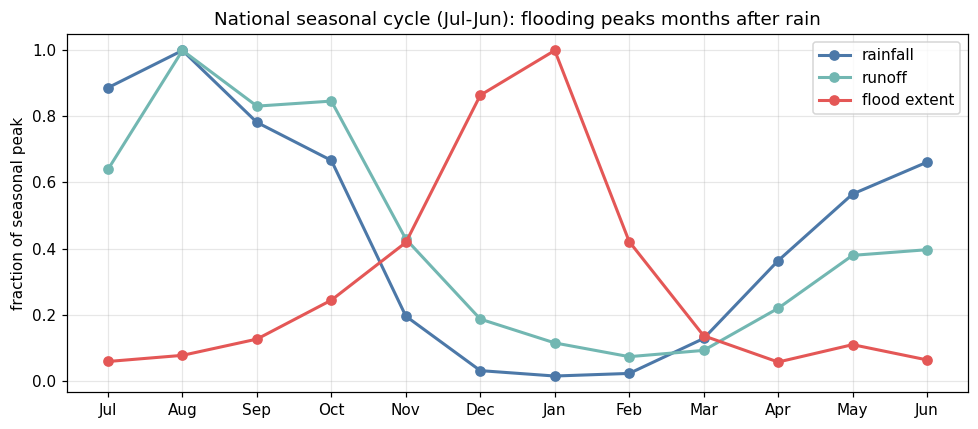

In [13]:
wy = lambda s: s.reindex(WY_ORDER)
clim = pd.DataFrame({
    "rainfall": wy(rain_ym.mean() / rain_ym.mean().max()),
    "runoff": wy(ro_ym.mean() / ro_ym.mean().max()),
    "flood extent": wy(share.mean() / share.mean().max()),
})
fig, ax = plt.subplots(figsize=(9, 4))
for c, col in zip(clim, ["#4c78a8", "#72b7b2", "#e45756"]):
    ax.plot(range(12), clim[c].values, marker="o", label=c, color=col, lw=2)
ax.set_xticks(range(12), WY_LABELS); ax.set_ylabel("fraction of seasonal peak"); ax.grid(alpha=0.3)
ax.set_title("National seasonal cycle (Jul-Jun): flooding peaks months after rain"); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "01_seasonal_timing.png", bbox_inches="tight")

# centre of mass on a Mar-Feb axis: rain (Apr-Oct) and the flood season (Oct-Feb) both sit
# inside it without wrapping; only the small Mar-Jun flood tail lands at the start
MF = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2]
pos = np.arange(12)
cen = {c: (clim[c].reindex(MF).values * pos).sum() / clim[c].sum() for c in clim}
print("centre of mass (months after 1 March):", {c: round(v, 1) for c, v in cen.items()})
print(f"flood centre lags rain by ~{(cen['flood extent'] - cen['rainfall']) * 30.4:.0f} days "
      f"and runoff by ~{(cen['flood extent'] - cen['runoff']) * 30.4:.0f} days")

In [14]:
# Does a wetter year nationally mean more flooding? Use MODIS-only seasons (2000-18) so the sensor
# change doesn't enter, and pair each rainy season with the flood season that follows it.
seas = pd.DataFrame({"rain": rain_ym.sum(axis=1), "runoff": ro_ym.sum(axis=1), "flood": ym.sum(axis=1)}).dropna()
pre = seas.loc[2003:2018]  # also drop the Terra-only years
detrend = lambda s: s - np.polyval(np.polyfit(s.index, s, 1), s.index)
for x in ["rain", "runoff"]:
    r_raw = stats.pearsonr(pre[x], pre.flood)
    r_dt = stats.pearsonr(detrend(pre[x]), detrend(pre.flood))
    print(f"{x:>7} vs national flood season, 2003-18 (n={len(pre)}): raw r = {r_raw[0]:+.2f} (p={r_raw[1]:.2f}), "
          f"detrended r = {r_dt[0]:+.2f} (p={r_dt[1]:.2f})")

   rain vs national flood season, 2003-18 (n=16): raw r = +0.24 (p=0.37), detrended r = +0.48 (p=0.06)
 runoff vs national flood season, 2003-18 (n=16): raw r = +0.27 (p=0.32), detrended r = +0.48 (p=0.06)


Nationally, the centre of the flood season comes **about 4 months (~115 days) after the centre of the
rainy season**, with runoff in between.

Across years, a wetter rainy season goes with a bigger following flood season only once both series
are detrended: r rises from +0.24 to **+0.48**. That is suggestive but not significant (p = 0.06,
n = 16 MODIS-only seasons). Two lessons:
- **Detrending matters.** The opposite trends in ERA5 rain and detections hide half of the relationship.
- **The national link is too noisy to act on.** It explains about a quarter of the variance at best.

A likely reason is that the **national aggregate mixes systems that behave
differently**: the Sudd, fed by the White Nile and Lake Victoria outflow from Uganda, which responds
slowly; and smaller river basins like the Lol that may respond to local rain. The national
signal is dominated by the biggest system, the Sudd.

## 6. What this tells us, and what comes next

| Finding | Consequence |
|---|---|
| Flood product ends at 10°N; no cloud information; absences may be unobserved, not dry | Extent is a lower bound; the north of Upper Nile cannot be studied |
| Detections are ~14× higher after 2020 (VIIRS added); 2000-02 suspiciously low | Interannual comparisons use normalised extent; 2000-02 flagged |
| Flooding concentrates in the Sudd, the Bahr el Jebel corridor, the Machar marshes and the north-western channels, in the drier half of the country | Water arriving from upstream matters; drivers must be studied **per region** |
| National flood season peaks in January, about 5 months after the August rain peak; since 2019 floods persist into the dry season | Timing is regular, so **severity** is the open question; the slow response needs upstream drivers (lakes, discharge) tested |
| ERA5 rain has a strong, significant drying trend that conflicts with flood history | Detrend before correlating; cross-check against CHIRPS |
| Runoff is a small, more variable fraction of rain and stays high into October | Candidate measure of late-season ground saturation |
| National rain-flood link appears only after detrending (+0.48, p = 0.06) | Detrend everything; the national scale is too mixed, so look at counties and regions |

**Next notebook (02):** county-level flood statistics (which counties flood most, and are ZOA's among
them?), lake levels and discharge as upstream drivers, evapotranspiration, and the population map.